<a href="https://colab.research.google.com/github/GilangAngga12/pcd/blob/main/Salinan_dari_pert13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install mahotas

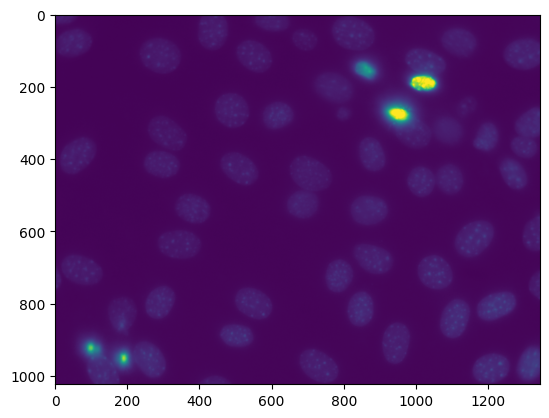

In [ ]:
import mahotas as mh
import mahotas.demos
import numpy as np
from pylab import imshow, show

f = mh.demos.nuclear_image()
f = f[:,:,0]

imshow(f)
show()

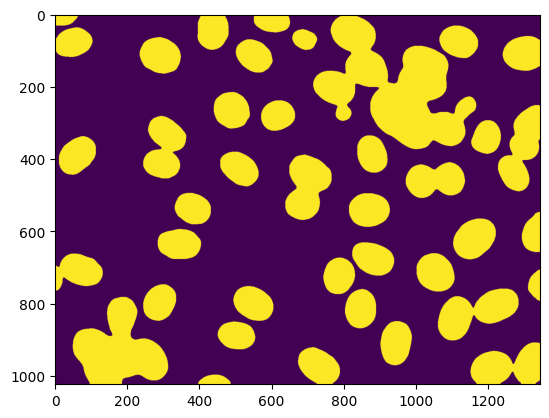

In [ ]:
f = mh.gaussian_filter(f, 4)
f = (f> f.mean())

f = mh.gaussian_filter(f, 4)
f = (f> f.mean())

imshow(f)
show()

In [ ]:
labeled, n_nucleus = mh.label (f)
print('Found {} nuclei.'.format(n_nucleus))

Found 40 nuclei.


Found 40 nuclei.


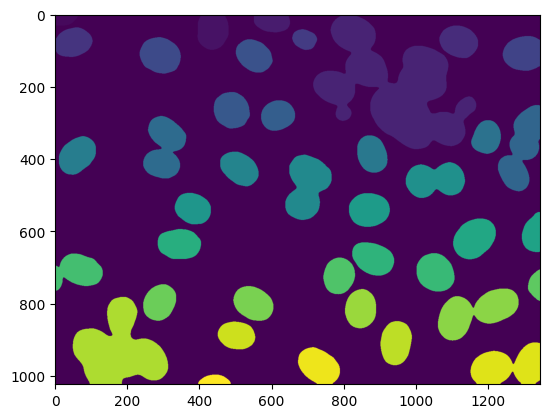

In [ ]:
labeled, n_nucleus = mh.label (f)
print('Found {} nuclei.'.format(n_nucleus))

imshow(labeled)
show()

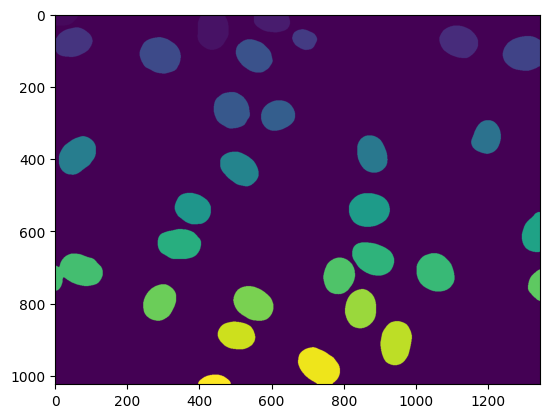

In [ ]:
sizes = mh.labeled.labeled_size(labeled)
too_big = np.where(sizes > 10000)
labeled = mh.labeled.remove_regions(labeled,too_big)

sizes = mh.labeled.labeled_size(labeled)
too_big = np.where(sizes > 10000)
labeled = mh.labeled.remove_regions (labeled,too_big)

imshow(labeled)
show()

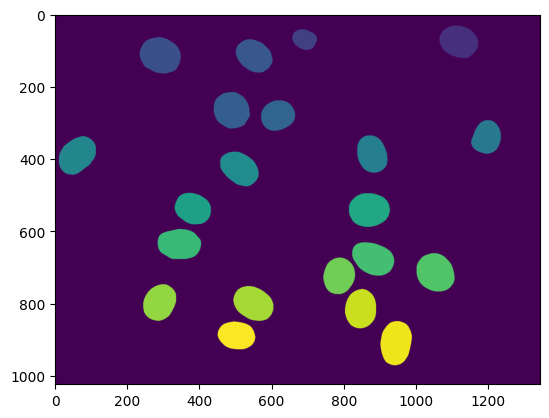

In [ ]:
labeled = mh.labeled.remove_bordering(labeled)
labeled = mh.labeled.remove_bordering(labeled)

imshow(labeled)
show()

In [ ]:
relabeled, n_left = mh.labeled.relabel (labeled)
print('After filtering and relabeling, '
'there are {} nuclei left.'.format(n_left))

After filtering and relabeling, there are 21 nuclei left.


After filtering and relabeling, there are 21 nuclei left.


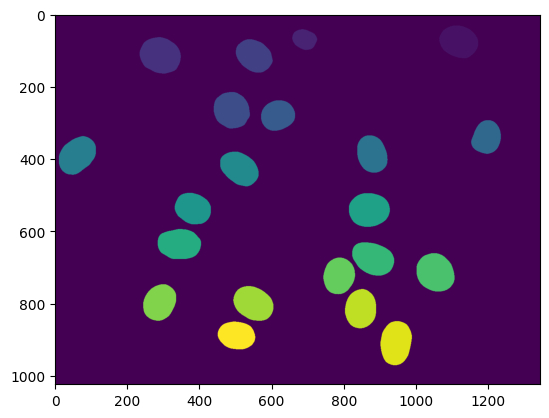

In [ ]:
relabeled, n_left =mh.labeled.relabel (labeled)
print('After filtering and relabeling, ''there are {} nuclei left.'.format(n_left))

imshow(relabeled)
show()

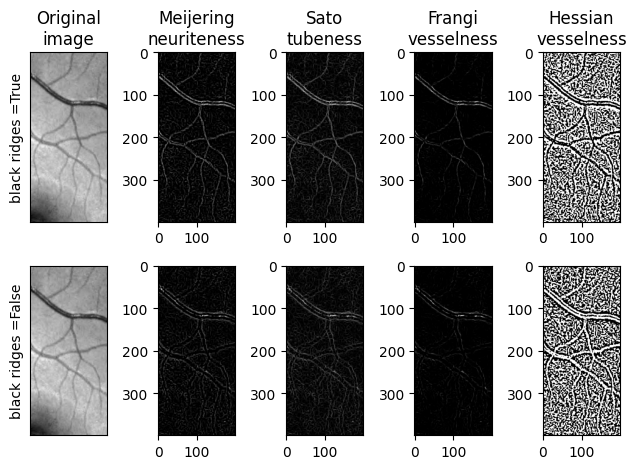

In [ ]:
from skimage import data
from skimage import color
from skimage.filters import meijering, sato, frangi, hessian
import matplotlib.pyplot as plt

def identity(image, **kwargs):
  """Return the original image, ignoring anykwargs."""
  return image

image = color.rgb2gray(data.retina()) [300:700,700:900]
cmap = plt.cm.gray
kwargs = {'sigmas': [1], 'mode': 'reflect'}
fig, axes = plt.subplots(2, 5)
for i, black_ridges in enumerate([1, 0]):
  for j, func in enumerate([identity, meijering, sato, frangi, hessian]):
    kwargs['black_ridges'] = black_ridges
    result = func(image, **kwargs)
    axes[i, j].imshow(result, cmap=cmap,aspect='auto')
    if i == 0:
        axes[i,j].set_title(['Original\nimage', 'Meijering\nneuriteness', 'Sato\ntubeness', 'Frangi\nvesselness' , 'Hessian\nvesselness'][j])
    if j == 0:
      axes[i,j].set_ylabel('black ridges =' + str(bool (black_ridges)))
      axes[i,j].set_xticks([])
      axes[i,j].set_yticks([])

plt.tight_layout()
plt.show()

**Layar depan**

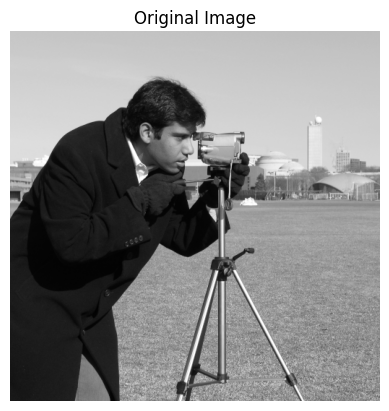

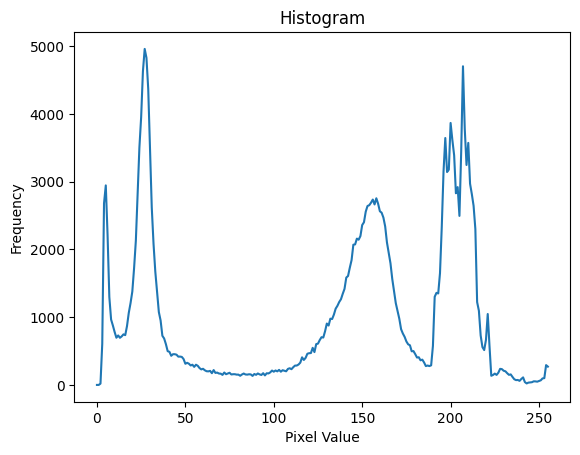

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

#load data
image = data.camera()

# generate ke bin
hist, bins = np.histogram(image, 256,[0, 256])

# menampilkan gambar asli
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# menapilkan histogram
plt.plot(hist)
plt.title('Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

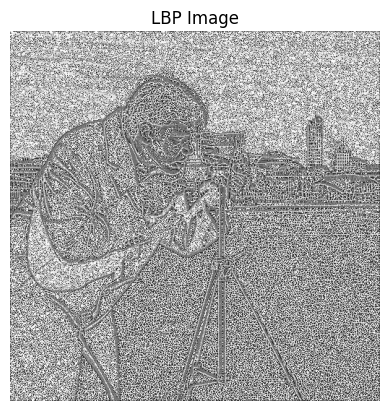

In [ ]:
from skimage.feature import local_binary_pattern

radius = 1
n_points = 8 * radius

lbp = local_binary_pattern(image, n_points, radius, method = 'uniform')

#show LBP image
plt.imshow(lbp, cmap = 'gray')
plt.title('LBP Image')
plt.axis('off')
plt.show()

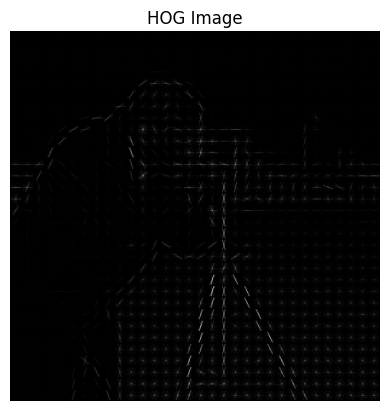

In [ ]:
from skimage.feature import hog

hog_feature, hog_image = hog(image,
                             pixels_per_cell = (16, 16),
                             cells_per_block = (4, 4),
                             visualize = True )

#show HOG image
plt.imshow(hog_image, cmap = 'gray')
plt.title('HOG Image')
plt.axis('off')
plt.show()

Contrast:  [[237.27839484]]
Dissimilarity:  [[6.96957941]]
Homogeneity:  [[0.3971393]]
Energy:  [[0.04169838]]
Correlation:  [[0.97812712]]


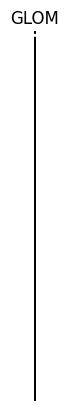

In [ ]:
from skimage.feature import graycomatrix, graycoprops

glcm = graycomatrix(
    image,
    distances=[1],
    angles=[0],
    levels= 256,
    symmetric= True,
    normed= True
)


contrast = graycoprops(glcm, 'contrast')
diesmilitary = graycoprops(glcm, 'dissimilarity')
homogeneity = graycoprops(glcm, 'homogeneity')
energy = graycoprops(glcm, 'energy')
correlation = graycoprops(glcm, 'correlation')

print('Contrast: ', contrast)
print('Dissimilarity: ', diesmilitary)
print('Homogeneity: ', homogeneity)
print('Energy: ', energy)
print('Correlation: ', correlation)
#show GLOM
plt.imshow(glcm[0, :, :, 0], cmap = 'gray')
plt.title('GLOM')
plt.axis('off')
plt.show()

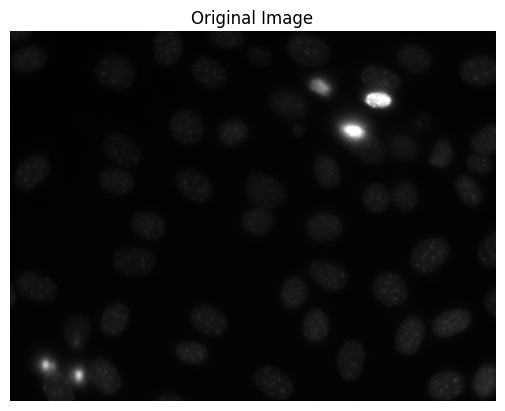

In [ ]:
import mahotas as mh

image = mh.demos.nuclear_image()

image = image[:,:,0]

plt.imshow(image, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

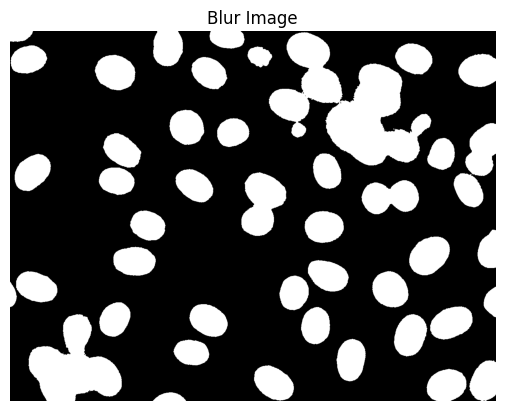

In [ ]:
image_blur = mh.gaussian_filter(image, sigma=1)

binary= image_blur > image_blur.mean()

plt.imshow(binary, cmap = 'gray')
plt.title('Blur Image')
plt.axis('off')
plt.show()

Found 47 objects.


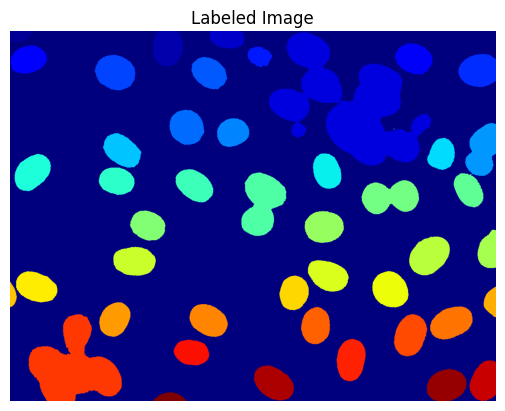

In [ ]:
labeled, n_objects = mh.label(binary)

print('Found {} objects.'.format(n_objects))

plt.imshow(labeled, cmap = 'jet')
plt.title('Labeled Image')
plt.axis('off')
plt.show()

jumlah objek akhir: 33


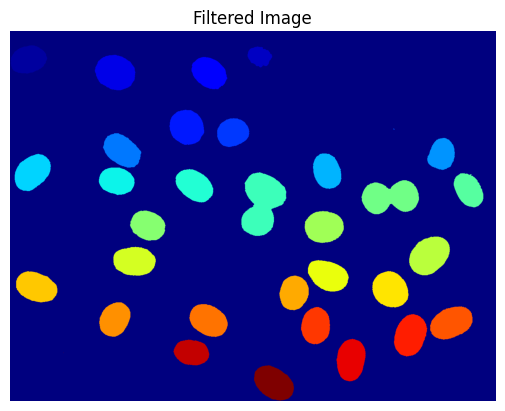

In [ ]:
sizes = mh.labeled.labeled_size(labeled)
labeled = mh.labeled.remove_regions(labeled, sizes > 10000)

labeled = mh.labeled.remove_bordering(labeled)

labeled, n_objects = mh.labeled.relabel(labeled)
print(f"jumlah objek akhir: {n_objects}")

plt.imshow(labeled, cmap = 'jet')
plt.title('Filtered Image')
plt.axis('off')
plt.show()

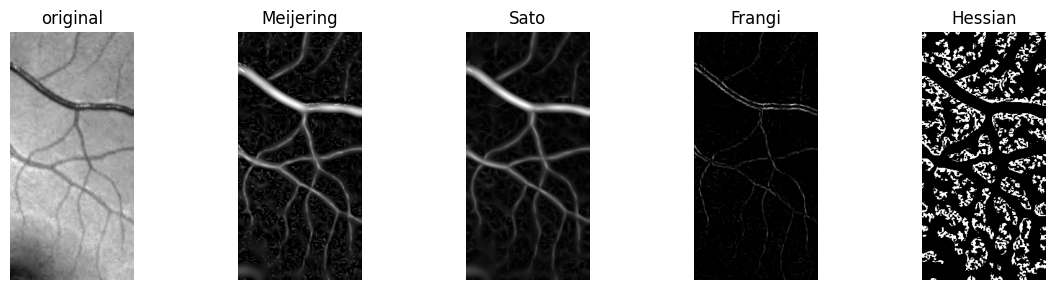

In [ ]:
from skimage import data, filters
import matplotlib.pyplot as plt

image = color.rgb2gray(data.retina())[300:700, 700:900]

filters_list = {
    "original": lambda x: x,
    "Meijering": filters.meijering,
    "Sato": filters.sato,
    "Frangi": filters.frangi,
    "Hessian": filters.hessian
}

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for ax, (name, func) in zip(axes, filters_list.items()):
    ax.imshow(func(image), cmap='gray')
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()

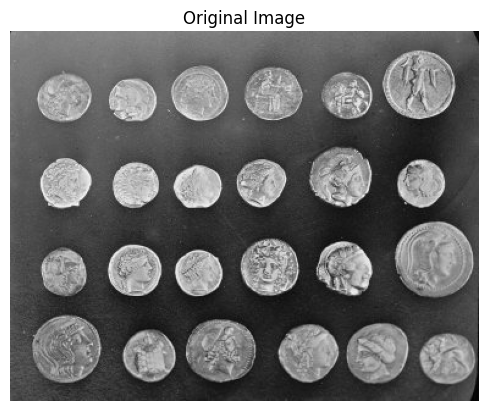

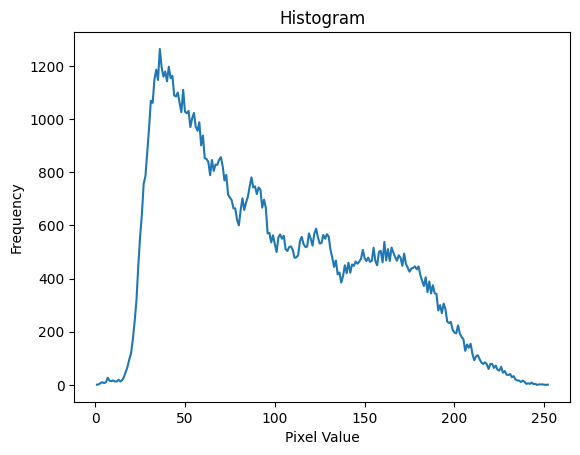

In [ ]:
from skimage import data
from skimage.exposure import histogram

coine = data.coins()

hist, centers = histogram(coine)

plt.imshow(coine, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

plt.plot(centers, hist)
plt.title('Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

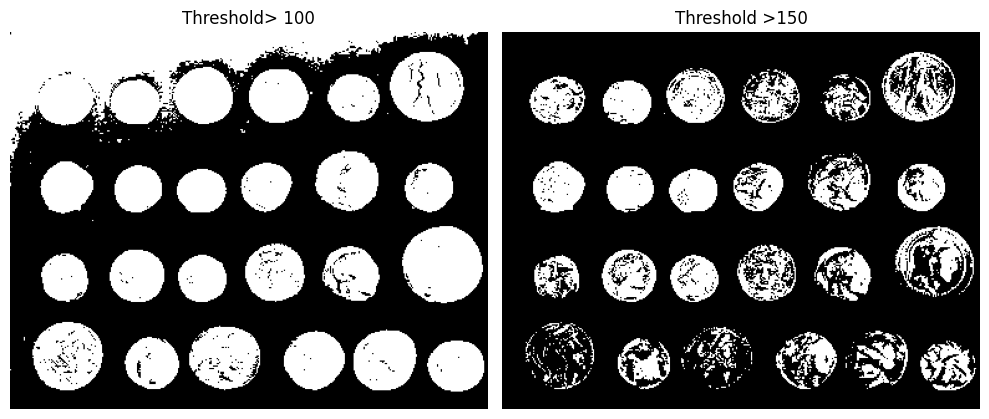

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(coine > 100, cmap = 'gray')
ax[0].set_title('Threshold> 100')
ax[0].axis('off')

ax[1].imshow(coine > 150, cmap= 'gray')
ax[1].set_title('Threshold >150')
ax[1].axis('off')

plt.tight_layout()
plt.show()

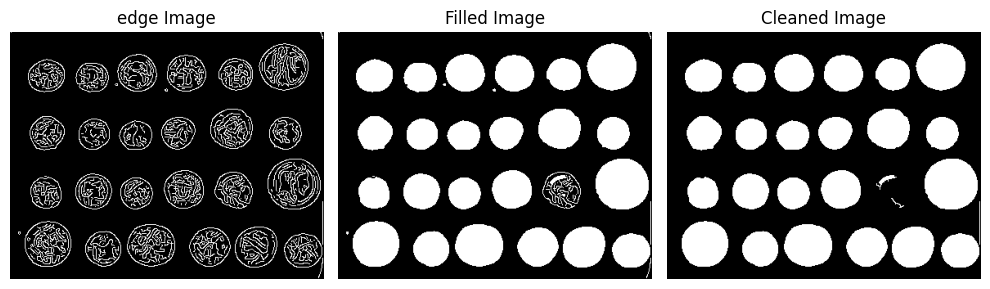

In [ ]:
from skimage.feature import canny
from scipy import ndimage as ndi
from skimage import morphology

edges = canny(coine)
filled = ndi.binary_fill_holes(edges)
cleaned = morphology.remove_small_objects(filled, 21)
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].imshow(edges, cmap='gray')
ax[0].set_title('edge Image')
ax[0].axis('off')

ax[1].imshow(filled, cmap='gray')
ax[1].set_title('Filled Image')
ax[1].axis('off')

ax[2].imshow(cleaned, cmap='gray')
ax[2].set_title('Cleaned Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

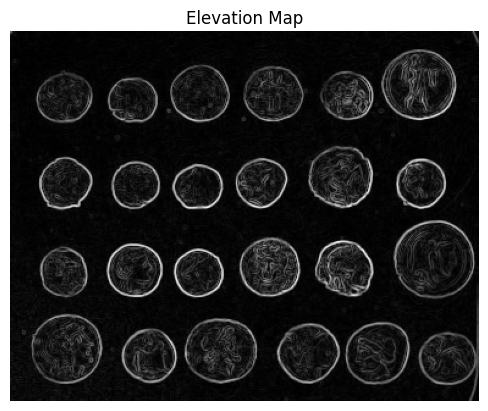

In [ ]:
from skimage.filters import sobel
elevation_map = sobel(coine)

plt.imshow(elevation_map, cmap='gray')
plt.title('Elevation Map')
plt.axis('off')
plt.show()


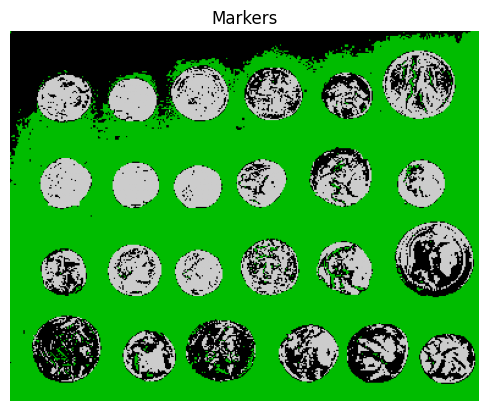

In [ ]:
markers = np.zeros_like(coine)
markers[coine < 100] = 1
markers[coine > 150] = 2

plt.imshow(markers, cmap='nipy_spectral')
plt.title('Markers')
plt.axis('off')
plt.show()

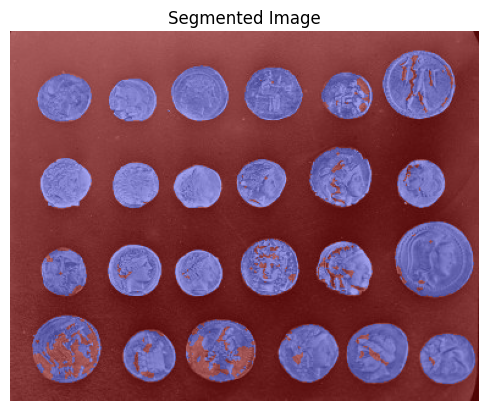

In [ ]:
from skimage.filters import sobel
from skimage.segmentation import watershed
from skimage.color import label2rgb

# elevation_map = sobel(coine)

segments = watershed(elevation_map, markers)
overlay = label2rgb(segments, image=coine, bg_label=0)

plt.imshow(overlay)
plt.title('Segmented Image')
plt.axis('off')
plt.show()